# Public Health Modeling Lab (Systems + Quadratics)
**Name:** _______________________  **Period:** ____  **Date:** ____

### Big idea
This lab is about **how math can inform decisions**. You will use:
- **Systems of equations** to compare two strategies (where do they agree? which is better where?)
- **Quadratics** to model **diminishing returns** and find an **optimal** spending level

✅ **How you will turn this in:** Run the last cell to export a text file of your answers, then submit that file.

---

# Laboratorio de Modelación de Salud Pública (Sistemas + Cuadráticas)
**Nombre:** _______________________  **Período:** ____  **Fecha:** ____

### Idea principal
Este laboratorio trata de **cómo las matemáticas pueden apoyar decisiones**. Vas a usar:
- **Sistemas de ecuaciones** para comparar dos estrategias (¿dónde coinciden? ¿cuál es mejor y cuándo?)
- **Cuadráticas** para modelar **rendimientos decrecientes** y encontrar un nivel **óptimo** de gasto

✅ **Cómo lo vas a entregar:** Ejecuta la última celda para exportar un archivo de texto con tus respuestas y súbelo.

## How to use this notebook (Accountability)
You will see **Checkpoints** throughout the lab.

At each checkpoint you will:
1. Type your answer into a variable like `ans_1 = ...`
2. Run the cell
3. You’ll get an automatic “Looks good” message (or a hint)

At the end, you will run **Export Answers** to save a `.txt` file with all your responses.

---

## Cómo usar este cuaderno (Responsabilidad)
Vas a ver **Puntos de control** durante el laboratorio.

En cada punto de control:
1. Escribe tu respuesta en una variable como `ans_1 = ...`
2. Ejecuta la celda
3. Recibirás un mensaje automático de “✅ Bien” (o una pista)

Al final, ejecutarás **Exportar respuestas** para guardar un archivo `.txt` con todas tus respuestas.


### Graph files (saved automatically) / Archivos de gráficas (guardados automáticamente)
When you run the two graph cells, this notebook saves:
- `systems_model.png`
- `quadratic_optimization.png`

At the end, the export cell will rename them with your name and period and you will submit **3 files total**:
1) your answers `.txt` file  
2) your systems graph `.png`  
3) your quadratic graph `.png`  

---

Cuando ejecutes las dos celdas de gráficas, este cuaderno guarda:
- `systems_model.png`
- `quadratic_optimization.png`

Al final, la celda de exportación los renombrará con tu nombre y período y entregarás **3 archivos**:
1) respuestas `.txt`  
2) gráfica de sistemas `.png`  
3) gráfica cuadrática `.png`


In [1]:

# Run this cell first / Ejecuta esta celda primero.
import math
import numpy as np
import matplotlib.pyplot as plt

answers = {}

def record(key, value):
    answers[key] = value

def check_close(key, student, target, tol=1e-2, hint_en="Try again. Re-check your arithmetic or graph reading.",
                hint_es="Intenta de nuevo. Revisa tu aritmética o la lectura de la gráfica."):
    record(key, student)
    if isinstance(student, (int, float)) and abs(student - target) <= tol:
        print("✅ Looks good / Se ve bien.")
        return True
    else:
        print("❌ Not quite / No todavía.", hint_en, "|", hint_es)
        return False

def check_text(key, student, min_len=15):
    record(key, student)
    if isinstance(student, str) and len(student.strip()) >= min_len:
        print("✅ Recorded / Registrado.")
        return True
    else:
        print("❌ Please write a bit more / Escribe un poco más (por lo menos una oración).")
        return False


## Part 1 — Warm-up: A system is a point of agreement
A **system** is two relationships about the same situation.

A solution is a point \((x,y)\) where **both** relationships are true at the same time.

---

## Parte 1 — Calentamiento: Un sistema es un punto de acuerdo
Un **sistema** son dos relaciones sobre la misma situación.

Una solución es un punto \((x,y)\) donde **ambas** relaciones son verdaderas al mismo tiempo.

### Example system (easy numbers)
\[
\begin{aligned}
x + y &= 9\\
x - y &= 1
\end{aligned}
\]

We will solve it **two ways**:
1) by reasoning with equations, and  
2) by a **matrix** viewpoint (a structural tool).

---

### Sistema de ejemplo (números fáciles)
\[
\begin{aligned}
x + y &= 9\\
x - y &= 1
\end{aligned}
\]

Lo vamos a resolver de **dos maneras**:
1) razonando con ecuaciones, y  
2) con una vista de **matriz** (una herramienta estructural).

In [2]:

# Solve by quick reasoning / Resolver con razonamiento rápido
# (x+y) + (x-y) = 9 + 1  ->  2x = 10  ->  x = 5  -> y = 4
x_sol = 5
y_sol = 4
x_sol, y_sol


(5, 4)

### Checkpoint 1 (interpretation)
In one sentence: what does \((5,4)\) mean for this system?

---

### Punto de control 1 (interpretación)
En una oración: ¿qué significa \((5,4)\) para este sistema?

In [3]:

ans_1 = ""  # Write a complete sentence / Escribe una oración completa.
check_text("CP1_interpretation", ans_1)


❌ Please write a bit more / Escribe un poco más (por lo menos una oración).


False

## Part 2 — Two ways to solve (and what we notice)
We just solved a system. Now we will compare **two approaches**:

- **Elimination (by hand):** combine equations to “cancel” a variable  
- **Matrix / computer approach:** treat the system as a transformation and let a tool “undo the mixing”

You do **not** need to memorize matrix steps. The purpose is to notice what computers can do quickly.

---

## Parte 2 — Dos maneras de resolver (y lo que notamos)
Acabamos de resolver un sistema. Ahora vamos a comparar **dos enfoques**:

- **Eliminación (a mano):** combinar ecuaciones para “cancelar” una variable  
- **Matriz / enfoque de computadora:** tratar el sistema como una transformación y usar una herramienta para “deshacer la mezcla”

No necesitas memorizar pasos de matrices. El propósito es notar lo que las computadoras pueden hacer rápidamente.

### Method A: Elimination (step-by-step)
\[
\begin{aligned}
x+y&=9\\
x-y&=1
\end{aligned}
\]

Add the equations:
\[
(x+y)+(x-y)=9+1 \Rightarrow 2x=10 \Rightarrow x=5
\]
Then substitute \(x=5\) into \(x+y=9\):
\[
5+y=9 \Rightarrow y=4
\]

---

### Método A: Eliminación (paso a paso)
\[
\begin{aligned}
x+y&=9\\
x-y&=1
\end{aligned}
\]

Suma las ecuaciones:
\[
(x+y)+(x-y)=9+1 \Rightarrow 2x=10 \Rightarrow x=5
\]
Luego sustituye \(x=5\) en \(x+y=9\):
\[
5+y=9 \Rightarrow y=4
\]

### Method B: Matrix / computer solve (demo)
Write the system as:
\[
A\begin{bmatrix}x\\y\end{bmatrix}=\begin{bmatrix}9\\1\end{bmatrix},
\quad
A=\begin{bmatrix}1&1\\1&-1\end{bmatrix}
\]

A computer can solve \(A\vec{x}=\vec{b}\) very fast (same idea as an inverse-matrix calculator).

---

### Método B: Resolver con matrices / computadora (demostración)
Escribe el sistema así:
\[
A\begin{bmatrix}x\\y\end{bmatrix}=\begin{bmatrix}9\\1\end{bmatrix},
\quad
A=\begin{bmatrix}1&1\\1&-1\end{bmatrix}
\]

Una computadora puede resolver \(A\vec{x}=\vec{b}\) muy rápido (misma idea que una calculadora de matrices inversas).

In [4]:

A = np.array([[1, 1],
              [1, -1]], dtype=float)
b = np.array([9, 1], dtype=float)

x = np.linalg.solve(A, b)   # same idea as using an inverse matrix calculator
x


array([5., 4.])

### Checkpoint 2 (notice & wonder)
Answer all three (1–2 sentences each):
1) What do you notice about the **elimination** method?
2) What do you notice about the **matrix/computer** method?
3) Which method do you think is **easier for a computer** to automate? Why?

---

### Punto de control 2 (notar y preguntarse)
Responde las tres (1–2 oraciones cada una):
1) ¿Qué notas sobre el método de **eliminación**?
2) ¿Qué notas sobre el método de **matriz/computadora**?
3) ¿Qué método crees que es **más fácil para automatizar** en una computadora? ¿Por qué?

In [5]:
ans_2a = ""  # elimination notice / nota sobre eliminación
ans_2b = ""  # matrix notice / nota sobre matriz
ans_2c = ""  # which easier for computer and why / cuál es más fácil para la computadora y por qué

check_text("CP2a_notice_elimination", ans_2a, min_len=25)
check_text("CP2b_notice_matrix", ans_2b, min_len=25)
check_text("CP2c_computer_automation", ans_2c, min_len=25)

❌ Please write a bit more / Escribe un poco más (por lo menos una oración).
❌ Please write a bit more / Escribe un poco más (por lo menos una oración).
❌ Please write a bit more / Escribe un poco más (por lo menos una oración).


False

## Part 3 — Public health context: Spending vs longevity
We will model a simplified relationship:

- **x = healthcare spending per person (per capita)** in dollars
- **y = average longevity (life expectancy)** in years

---

## Parte 3 — Contexto de salud pública: Gasto vs longevidad
Vamos a modelar una relación simplificada:

- **x = gasto en salud por persona (per cápita)** en dólares
- **y = longevidad promedio (esperanza de vida)** en años

### The dataset (toy but realistic-looking)
Below is a simplified dataset showing spending levels and an observed longevity outcome.
Notice the curve shape (diminishing returns).

---

### El conjunto de datos (simple pero realista)
Abajo hay datos simplificados que muestran niveles de gasto y un resultado observado de longevidad.
Observa la forma curva (rendimientos decrecientes).

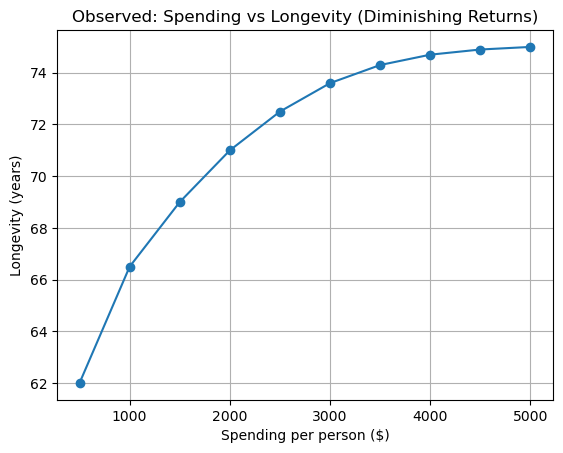

In [6]:

x_data = np.array([ 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000], dtype=float)
y_data = np.array([ 62.0, 66.5, 69.0, 71.0, 72.5, 73.6, 74.3, 74.7, 74.9, 75.0], dtype=float)

plt.figure()
plt.plot(x_data, y_data, marker='o')
plt.xlabel("Spending per person ($)")
plt.ylabel("Longevity (years)")
plt.title("Observed: Spending vs Longevity (Diminishing Returns)")
plt.grid(True)
plt.show()


### Checkpoint 3 (reading a graph)
Approximately how many years of longevity are gained when spending increases from \$500 to \$2000?

---

### Punto de control 3 (leer una gráfica)
Aproximadamente, ¿cuántos años de longevidad se ganan cuando el gasto sube de \$500 a \$2000?

In [9]:

ans_3 = 9.0
check_close("CP3_years_gained_500_to_2000", ans_3, 9.0, tol=0.25)


✅ Looks good / Se ve bien.


True

## Part 4 — Systems: Compare two strategies (curves) and find where they agree
Real relationships are often **curved** (diminishing returns). Here we will compare two **strategy curves**:

- **Infrastructure (I):** helps a lot early, then levels off (saturates)
- **Education (E):** grows more slowly at first, but keeps improving and can pass Infrastructure later

A **system** is still about agreement: the intersection is where both strategies predict the same longevity.

Then we will make a **local linear model** near the intersection (a zoomed-in line) so we can solve and compare more easily.

---

## Parte 4 — Sistemas: comparar dos estrategias (curvas) y encontrar dónde coinciden
Las relaciones reales a menudo son **curvas** (rendimientos decrecientes). Aquí compararemos dos **curvas de estrategia**:

- **Infraestructura (I):** ayuda mucho al principio y luego se nivela (se “satura”)
- **Educación (E):** crece más lento al principio, pero sigue mejorando y puede superar a Infraestructura después

Un **sistema** todavía significa acuerdo: la intersección es donde ambas estrategias predicen la misma longevidad.

Luego haremos un **modelo lineal local** cerca de la intersección (una recta “al hacer zoom”) para resolver y comparar más fácilmente.

**Note / Nota:** We used curves to represent diminishing returns. Then we used a *local line* near the intersection to compare and “solve” in a simpler way.

**Nota / Note:** Usamos curvas para representar rendimientos decrecientes. Luego usamos una *recta local* cerca de la intersección para comparar y “resolver” de forma más simple.

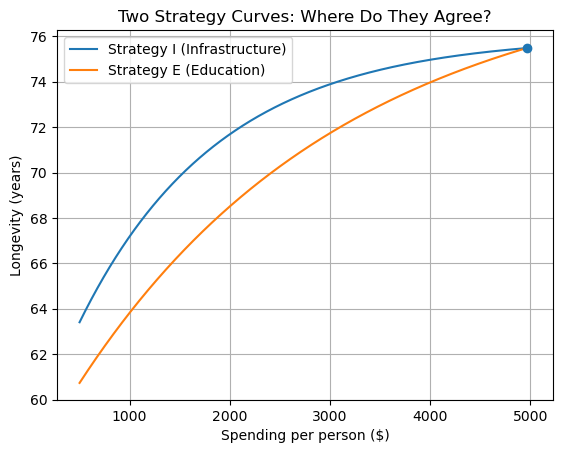

(np.float64(4960.974732294616), np.float64(75.47961253626964))

In [3]:
# Strategy curves (computer-generated, plausible shapes)
# Curves are used for interpretation; we will use a local linear model near the crossing.

def infra_curve(x):
    # Saturating curve: big early gains, then flattens
    return 58 + 18*(1 - np.exp(-x/1400))

def edu_curve(x):
    # Slower early, higher long-run ceiling
    return 57 + 21*(1 - np.exp(-x/2600)) + 0.6*(x/5000)

x_grid = np.linspace(500, 5000, 2000)
diff = infra_curve(x_grid) - edu_curve(x_grid)

# Find an approximate intersection where the difference changes sign
sign_change = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
if len(sign_change) == 0:
    idx = np.argmin(np.abs(diff))
    x_star = x_grid[idx]
else:
    i0 = sign_change[0]
    x1, x2 = x_grid[i0], x_grid[i0+1]
    y1, y2 = diff[i0], diff[i0+1]
    x_star = x1 - y1*(x2-x1)/(y2-y1)

y_star = infra_curve(x_star)

plt.figure()
plt.plot(x_grid, infra_curve(x_grid), label="Strategy I (Infrastructure)")
plt.plot(x_grid, edu_curve(x_grid), label="Strategy E (Education)")
plt.scatter([x_star], [y_star], zorder=5)
plt.xlabel("Spending per person ($)")
plt.ylabel("Longevity (years)")
plt.title("Two Strategy Curves: Where Do They Agree?")
plt.grid(True)
plt.legend()

plt.show()

x_star, y_star

In [ ]:
# Local linear models near the intersection (zoom-in line idea)
# Approximate slope using a small step (rate of change near the point)

h = 50  # small change in spending (dollars)
m_I = (infra_curve(x_star + h) - infra_curve(x_star - h)) / (2*h)
m_E = (edu_curve(x_star + h) - edu_curve(x_star - h)) / (2*h)

b_I = y_star - m_I*x_star
b_E = y_star - m_E*x_star

def y_I_local(x): return m_I*x + b_I
def y_E_local(x): return m_E*x + b_E

x_line = np.linspace(x_star-800, x_star+800, 200)

plt.figure()
plt.plot(x_grid, infra_curve(x_grid), label="Infrastructure curve")
plt.plot(x_grid, edu_curve(x_grid), label="Education curve")
plt.plot(x_line, y_I_local(x_line), label="Local line (I)")
plt.plot(x_line, y_E_local(x_line), label="Local line (E)")
plt.scatter([x_star], [y_star], zorder=5)
plt.xlabel("Spending per person ($)")
plt.ylabel("Longevity (years)")
plt.title("Local Linear Models Near the Intersection (Zoom-in)")
plt.grid(True)
plt.legend()
plt.savefig("systems_model.png", dpi=150, bbox_inches="tight")
plt.show()

(m_I, b_I, m_E, b_E)

### Checkpoint 4 (intersection)
1) Record the intersection \((x^*, y^*)\).  
2) Then answer: above the intersection, which strategy predicts **higher** longevity? below the intersection?

---

### Punto de control 4 (intersección)
1) Registra la intersección \((x^*, y^*)\).  
2) Luego responde: por encima de la intersección, ¿qué estrategia predice **mayor** longevidad? ¿y por debajo?

In [12]:
x_star, y_star

(np.float64(4960.974732294616), np.float64(75.47961253626964))

In [13]:

ans_4x = 0.0
ans_4y = 0.0
check_close("CP4_intersection_x", ans_4x, float(x_star), tol=25)
check_close("CP4_intersection_y", ans_4y, float(y_star), tol=0.2)


❌ Not quite / No todavía. Try again. Re-check your arithmetic or graph reading. | Intenta de nuevo. Revisa tu aritmética o la lectura de la gráfica.
❌ Not quite / No todavía. Try again. Re-check your arithmetic or graph reading. | Intenta de nuevo. Revisa tu aritmética o la lectura de la gráfica.


False

### Checkpoint 5 (interpretation)
Write 2–3 sentences interpreting the intersection:
- What does it mean?
- Which strategy is better below the intersection?
- Which strategy is better above the intersection?

---

### Punto de control 5 (interpretación)
Escribe 2–3 oraciones interpretando la intersección:
- ¿Qué significa?
- ¿Qué estrategia es mejor por debajo de la intersección?
- ¿Qué estrategia es mejor por encima de la intersección?

In [ ]:

ans_5 = ""
check_text("CP5_intersection_interpretation", ans_5, min_len=40)


## Part 5 — Matrix demonstration (optional but recommended)
We can solve the intersection as a 2×2 matrix system (same idea as an inverse-matrix calculator).

---

## Parte 5 — Demostración con matrices (opcional pero recomendable)
Podemos resolver la intersección como un sistema 2×2 con matrices (misma idea que una calculadora de inversas).

In [15]:

A2 = np.array([[m_I, -1],
               [m_E, -1]], dtype=float)
b2 = np.array([-b_I, -b_E], dtype=float)

sol = np.linalg.solve(A2, b2)
sol  # [x, y]


array([4960.97473229,   75.47961254])

### Checkpoint 6 (structural)
In 1–2 sentences: What does the matrix represent in the systems problem?

---

### Punto de control 6 (estructura)
En 1–2 oraciones: ¿qué representa la matriz en el problema de sistemas?

In [ ]:

ans_6 = ""
check_text("CP6_matrix_meaning", ans_6, min_len=30)


## Part 6 — Quadratics: optimization (diminishing returns)
We’ll fit a quadratic to the dataset and interpret the **vertex** (the “best point” of this model).

---

## Parte 6 — Cuadráticas: optimización (rendimientos decrecientes)
Ajustaremos una cuadrática a los datos e interpretaremos el **vértice** (el “mejor punto” de este modelo).

In [16]:

coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs
a, b, c


(np.float64(-8.969696969696896e-07),
 np.float64(0.007543030303030262),
 np.float64(59.24000000000001))

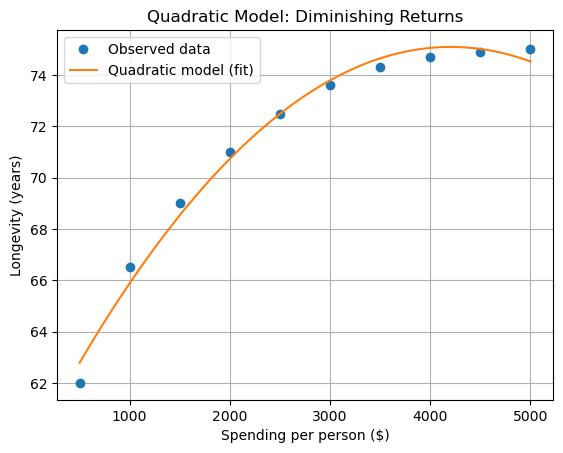

In [17]:

def y_quad(x): return a*x**2 + b*x + c
x_fit = np.linspace(500, 5000, 400)

plt.figure()
plt.plot(x_data, y_data, marker='o', linestyle='none', label="Observed data")
plt.plot(x_fit, y_quad(x_fit), label="Quadratic model (fit)")
plt.xlabel("Spending per person ($)")
plt.ylabel("Longevity (years)")
plt.title("Quadratic Model: Diminishing Returns")
plt.grid(True)
plt.legend()
plt.savefig("quadratic_optimization.png", dpi=150, bbox_inches="tight")
plt.show()


### Vertex
For \(y=ax^2+bx+c\): \(x_v=-\frac{b}{2a}\).

---

### Vértice
Para \(y=ax^2+bx+c\): \(x_v=-\frac{b}{2a}\).

In [ ]:

x_v = -b / (2*a)
y_v = y_quad(x_v)
x_v, y_v


### Checkpoint 7 (vertex values)
Record the vertex \((x_v, y_v)\).

---

### Punto de control 7 (valores del vértice)
Registra el vértice \((x_v, y_v)\).

In [18]:

ans_7x = 0.0
ans_7y = 0.0
check_close("CP7_vertex_x", ans_7x, float(x_v), tol=50)
check_close("CP7_vertex_y", ans_7y, float(y_v), tol=0.25)


<class 'NameError'>: name 'x_v' is not defined

### Checkpoint 8 (vertex interpretation)
Write 2–3 sentences:
- What does the vertex suggest about “optimal” spending in this simplified model?
- Why might the real world not match this perfectly?

---

### Punto de control 8 (interpretación del vértice)
Escribe 2–3 oraciones:
- ¿Qué sugiere el vértice sobre el gasto “óptimo” en este modelo simplificado?
- ¿Por qué el mundo real podría no coincidir perfectamente?

In [ ]:

ans_8 = ""
check_text("CP8_vertex_interpretation", ans_8, min_len=50)


## Part 7 — Brochure-ready takeaway (draft)
Write 3–5 sentences connecting:
- log scale (scale & change over time),
- systems comparison (tradeoffs),
- quadratic optimization (diminishing returns / vertex).

Write for a general audience.

---

## Parte 7 — Texto para el folleto (borrador)
Escribe 3–5 oraciones conectando:
- escala logarítmica (escala y cambio en el tiempo),
- comparación con sistemas (compensaciones),
- optimización con cuadráticas (rendimientos decrecientes / vértice).

Escribe para un público general.

In [ ]:

ans_9 = ""
check_text("CP9_brochure_paragraph", ans_9, min_len=80)


## Export Answers (RUN THIS LAST)
This creates a `.txt` file you can submit.

---

## Exportar respuestas (EJECUTA ESTO AL FINAL)
Esto crea un archivo `.txt` que puedes entregar.

In [ ]:

# Export answers + graphs / Exportar respuestas + gráficas

import os

last = input("Last name / Apellido: ").strip()
first = input("First name / Nombre: ").strip()
period = input("Period / Período: ").strip()

# 1) Export text answers / Exportar respuestas en texto
txt_name = f"answers_{last}_{first}_P{period}.txt".replace(" ", "_")
with open(txt_name, "w", encoding="utf-8") as f:
    f.write("Public Health Modeling Lab — Answers / Respuestas\n")
    f.write(f"Name/Nombre: {first} {last} | Period/Período: {period}\n\n")
    for k in sorted(answers.keys()):
        f.write(f"{k}: {answers[k]}\n\n")

# 2) Rename graphs if they were saved / Renombrar gráficas si existen
# These files are created automatically when you ran the graph cells.
# Estos archivos se crean automáticamente cuando ejecutas las celdas de gráficas.
systems_src = "systems_model.png"
quad_src = "quadratic_optimization.png"

systems_out = f"systems_{last}_{first}_P{period}.png".replace(" ", "_")
quad_out = f"quadratic_{last}_{first}_P{period}.png".replace(" ", "_")

if os.path.exists(systems_src):
    try:
        if os.path.exists(systems_out):
            os.remove(systems_out)
        os.rename(systems_src, systems_out)
        print(f"✅ Saved / Guardado: {systems_out}")
    except Exception as e:
        print("⚠️ Could not rename systems graph / No se pudo renombrar la gráfica de sistemas:", e)
else:
    print("⚠️ Systems graph not found. Re-run the systems graph cell. / No se encontró la gráfica de sistemas. Vuelve a ejecutar la celda de la gráfica.")

if os.path.exists(quad_src):
    try:
        if os.path.exists(quad_out):
            os.remove(quad_out)
        os.rename(quad_src, quad_out)
        print(f"✅ Saved / Guardado: {quad_out}")
    except Exception as e:
        print("⚠️ Could not rename quadratic graph / No se pudo renombrar la gráfica cuadrática:", e)
else:
    print("⚠️ Quadratic graph not found. Re-run the quadratic graph cell. / No se encontró la gráfica cuadrática. Vuelve a ejecutar la celda de la gráfica.")

print(f"✅ Exported / Exportado: {txt_name}")
print("Submit / Entrega: the .txt file AND the two .png files. / el archivo .txt Y los dos archivos .png.")
